# ALERTSENSE Visualization Tutorial

This notebook walks through a set of **exploratory and creative visualizations** for the ALERTSENSE dataset.

The dataset includes information on:
- Participant demographics (age, gender, race, education)
- Prior disaster experience
- Household and home characteristics
- Experimental condition and alert presentation
- Perceptions of the alert message (clarity, trust, relevance, influence, confidence, certainty)

You can use this notebook as a **teaching/demo tutorial** or as a starting point for your analysis.


## 1. Setup and Data Loading

In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

plt.style.use("default")
sns.set_theme(style="whitegrid")

# Display all columns 
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_PATH = "../data/mturk_data.csv"

df = pd.read_csv(DATA_PATH)
df.head()


,participant_id,age,participant_zipcode,participant_city,participant_state,gender,hispanic_or_latino,race,race_text,education,language,language_text,confidence_in_understanding_english,previous_disaster_experience,disaster1,location1,disaster2,location2,disaster3,location3,disaster4,location4,disaster5,location5,time1,time2,time3,time4,time5,family,occupation,dependents,medications,home_type,home_type_text,pet,fun_fact,condition,alert_display,selected_disaster,clarity,trust,relevance,influence,confidence,certainty
0,1,55-64,33573,Sun City Center,Florida,Male,No,White,NaN,Some college,English,NaN,Extremely,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,Self employed,Yes,Yes,Single family home,NaN,Yes,like to swim,1,Our county roads are experiencing the burden o...,Hurricane,4,4,5,4,4,4
1,2,45-54,77304,Conroe,Texas,Male,No,White,NaN,Bachelor’s degree (4-year college),English,NaN,Extremely,Yes,Flood,"Conroe,TX",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Between 1-10 years ago,NaN,NaN,NaN,NaN,Yes,FULL -TIME CORPORATE WORKER,Yes,Yes,Single family home,NaN,Yes,NaN,1,National Weather Service: A Flash flood warnin...,Flash flood,5,5,5,5,5,5
2,3,45-54,30345,Atlanta,Georgia,Male,No,White,NaN,Master’s degree,English,NaN,Extremely,Yes,Flood,"ATL,GA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Between 1-10 years ago,NaN,NaN,NaN,NaN,Yes,PROFESSOR IN LITERATURE,Yes,Yes,Apartment building,NaN,Yes,NaN,1,National Weather Service: A Hurricane warning ...,Hurricane,5,5,5,5,5,5
3,4,35-44,39047,Brandon,Mississippi,Female,Yes,Middle Eastern or North African,NaN,Master’s degree,English,NaN,Extremely,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,Technical assistant,No,Yes,Apartment building,NaN,No,NaN,1,National Weather Service: A Hurricane warning ...,Hurricane,3,5,5,5,5,5
4,5,25-34,97828,Enterprise,Oregon,Male,No,White,NaN,Bachelor’s degree (4-year college),English,NaN,Moderately,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,IT,Yes,Yes,Single family home,NaN,Yes,NaN,1,Prolonged heavy rain in the county is expected...,Flood,2,3,3,3,3,4


## 2. Quick Data Overview

We start with some basic checks to understand the structure of the dataset:
- Number of rows and columns
- Missing values per column
- Basic descriptive statistics


### 2.1 Columns 

In [2]:
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")

print("\nColumns:")
print(df.columns.tolist())


Shape: 503 rows x 46 columns

Columns:
['participant_id', 'age', 'participant_zipcode', 'participant_city', 'participant_state', 'gender', 'hispanic_or_latino', 'race', 'race_text', 'education', 'language', 'language_text', 'confidence_in_understanding_english', 'previous_disaster_experience', 'disaster1', 'location1', 'disaster2', 'location2', 'disaster3', 'location3', 'disaster4', 'location4', 'disaster5', 'location5', 'time1', 'time2', 'time3', 'time4', 'time5', 'family', 'occupation', 'dependents', 'medications', 'home_type', 'home_type_text', 'pet', 'fun_fact', 'condition', 'alert_display', 'selected_disaster', 'clarity', 'trust', 'relevance', 'influence', 'confidence', 'certainty']


### 2.2 Missing values per column

In [3]:
print("\nMissing values per column:")
print(df.isna().sum())


Missing values per column:
participant_id                           0
age                                      0
participant_zipcode                      0
participant_city                         0
participant_state                        0
gender                                   0
hispanic_or_latino                       0
race                                     0
race_text                              499
education                                0
language                                 0
language_text                          496
confidence_in_understanding_english      0
previous_disaster_experience             0
disaster1                              148
location1                              182
disaster2                              375
location2                              386
disaster3                              412
location3                              416
disaster4                              434
location4                              436
disaster5                 

### Descriptive Statistics

In [4]:
print("\nDescriptive statistics for numeric columns:")
display(df.describe())


Descriptive statistics for numeric columns:


,participant_id,participant_zipcode,condition,clarity,trust,relevance,influence,confidence,certainty
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,252.000000,55364.417495,1.186879,3.825050,3.962227,3.789264,3.757455,3.803181,3.673956
std,145.347859,29963.413553,0.390202,1.049193,0.986242,1.011549,1.031776,1.038612,1.099193
min,1.000000,1022.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,126.500000,30305.000000,1.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,252.000000,47802.000000,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,377.500000,85696.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,503.000000,99502.000000,2.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## 3. Participant Demographics

In this section we visualize core demographic variables such as **Age**, **Gender**, and **Education**.

These plots are useful for:
- Understanding who is represented in the sample
- Checking for imbalances between groups


### 3.1 Age Distribution

If `age` is categorical (e.g., age brackets), we plot counts for each group.


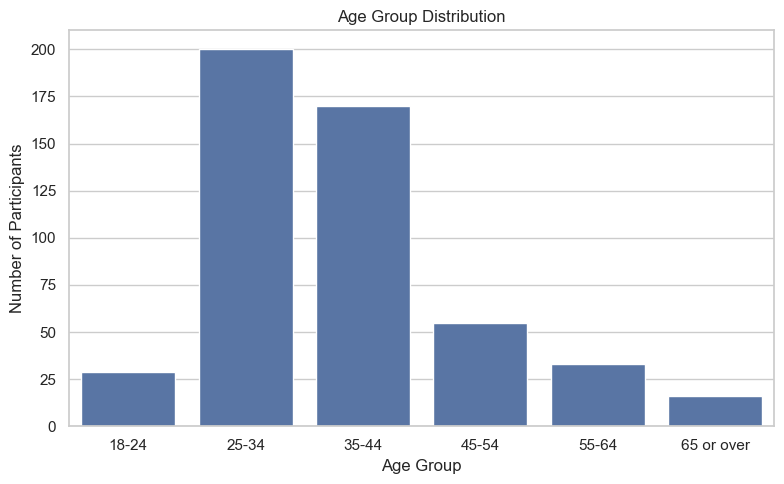

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

if pd.api.types.is_numeric_dtype(df["age"]):
    ax.hist(df["age"].dropna(), bins=10)
    ax.set_xlabel("Age")
    ax.set_ylabel("Number of Participants")
    ax.set_title("Age Distribution")
else:
    age_counts = (
        df["age"]
        .astype("category")
        .value_counts()
        .sort_index()
    )
    sns.barplot(x=age_counts.index, y=age_counts.values, ax=ax)
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Number of Participants")
    ax.set_title("Age Group Distribution")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### 3.2 Gender Distribution

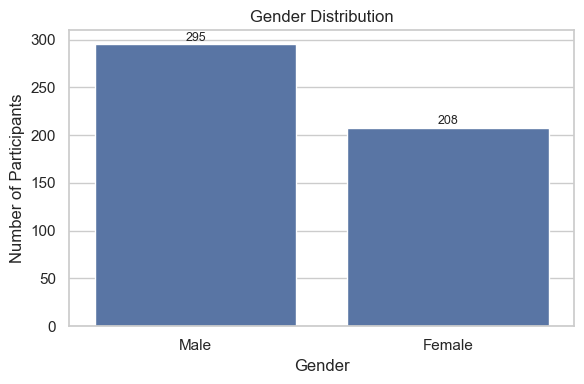

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

# Convert to dataframe
gender_counts = (
    df["gender"]
    .fillna("Missing")
    .astype("category")
    .value_counts()
    .rename_axis("gender")
    .reset_index(name="Count")
)

order = gender_counts["gender"].tolist()

sns.barplot(data=gender_counts, x="gender", y="Count", ax=ax, order=order)

ax.set_xlabel("Gender")
ax.set_ylabel("Number of Participants")
ax.set_title("Gender Distribution")
ax.tick_params(axis="x", rotation=0)

# annotate
for i, row in gender_counts.iterrows():
    ax.text(i, row["Count"] + 0.5, str(row["Count"]),
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

### 3.3 Education Level

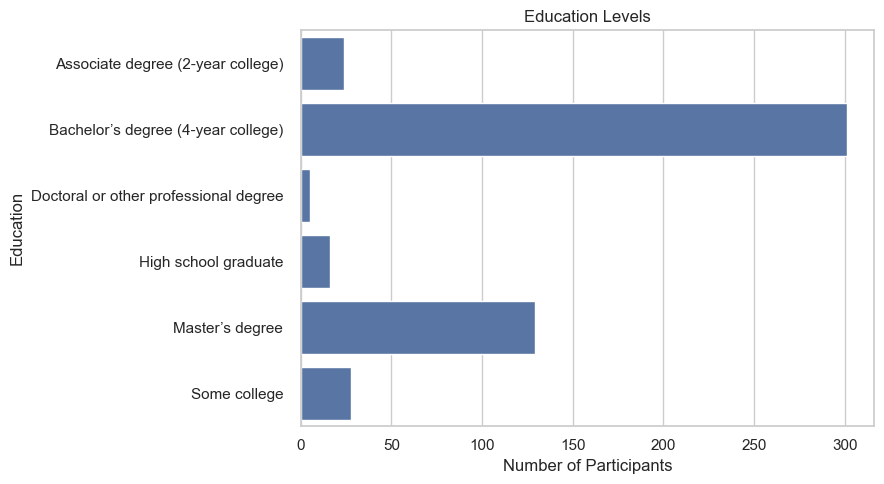

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

edu_counts = (
    df["education"]
    .fillna("Missing")
    .astype("category")
    .value_counts()
)

sns.barplot( x=edu_counts.values, y=edu_counts.index, ax=ax)
ax.set_xlabel("Number of Participants")
ax.set_ylabel("Education")
ax.set_title("Education Levels")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 4. Previous Disaster Experience

The dataset includes up to **five prior disaster experiences** (`disaster1`–`disaster5`) with corresponding locations and timestamps.

We can derive and visualize:
- Whether a participant has **any** prior disaster experience
- The **number of disasters** each participant reports


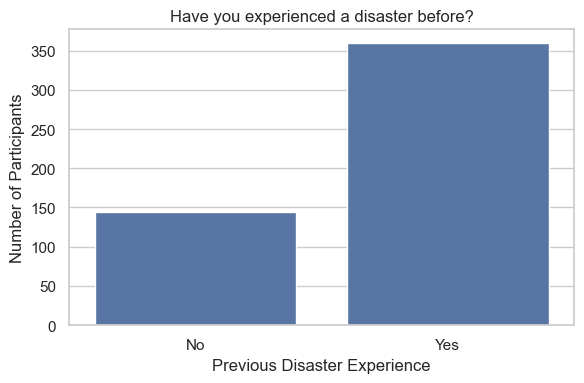

In [8]:
# 4.1 Any previous disaster experience (Yes/No)

fig, ax = plt.subplots(figsize=(6, 4))

exp_counts = (
    df["previous_disaster_experience"]
    .fillna("Missing")
    .astype("category")
    .value_counts()
)

sns.barplot(x=exp_counts.index, y=exp_counts.values, ax=ax)
ax.set_xlabel("Previous Disaster Experience")
ax.set_ylabel("Number of Participants")
ax.set_title("Have you experienced a disaster before?")
plt.tight_layout()
plt.show()


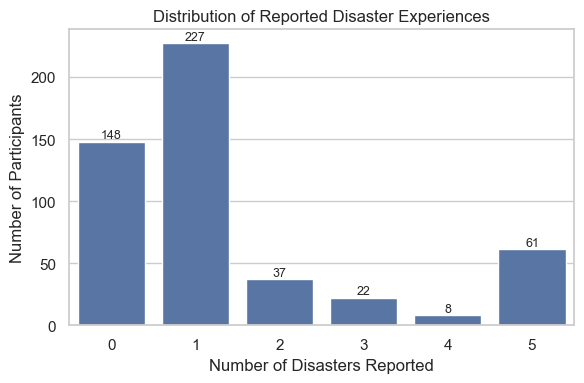

In [9]:
# 4.2 Number of disasters reported per participant

disaster_cols = ["disaster1", "disaster2", "disaster3", "disaster4", "disaster5"]

df["num_disasters_reported"] = df[disaster_cols].notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
counts = df["num_disasters_reported"].value_counts().sort_index()

sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
ax.set_xlabel("Number of Disasters Reported")
ax.set_ylabel("Number of Participants")
ax.set_title("Distribution of Reported Disaster Experiences")

for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


### 4.3 Geographic Distribution of Participants (by State)

Using `participant_state`, we can draw a **choropleth map** of participant counts across the U.S.


In [10]:
import plotly.express as px
import pandas as pd

# Aggregate by Participant_State
state_counts = (
    df.groupby("participant_state")
      .size()
      .reset_index(name="participant_count")
      .rename(columns={"participant_state": "state"})
)

# Drop missing
state_counts = state_counts[state_counts["state"].notna()].copy()

# 2) Map full state names to 2-letter abbreviations
us_state_abbrev = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
}

total_counts = (
    df.groupby("participant_state")
      .size()
      .reset_index(name="participant_count")
      .rename(columns={"participant_state": "state"})
)

# Condition-wise counts per state
cond_counts = (
    df.groupby(["participant_state", "condition"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
      .rename(columns={"participant_state": "state"})
)

cond_counts = cond_counts.rename(columns={1: "condition_1_count", 2: "condition_2_count"})

state_counts = total_counts.merge(cond_counts, on="state", how="left")

# Clean and map to state codes
state_counts["state_code"] = (
    state_counts["state"]
    .astype(str)
    .str.strip()
    .replace(us_state_abbrev) 
    .str.upper()
)

# Choropleth
fig = px.choropleth(
    state_counts,
    locations="state_code",
    locationmode="USA-states",
    color="participant_count",
    scope="usa",
    color_continuous_scale="Viridis",
    hover_name="state",
    hover_data={
        "state_code": True,
        "participant_count": True,
        "condition_1_count": True,
        "condition_2_count": True
    },
    title="Geographic Distribution of Participants (by State and Condition)"
)

fig.show()

## 5. Household and Home Characteristics

We now look at variables that describe participants' context:
- **family** structure
- **dependents**
- **home_type**
- **pet** ownership


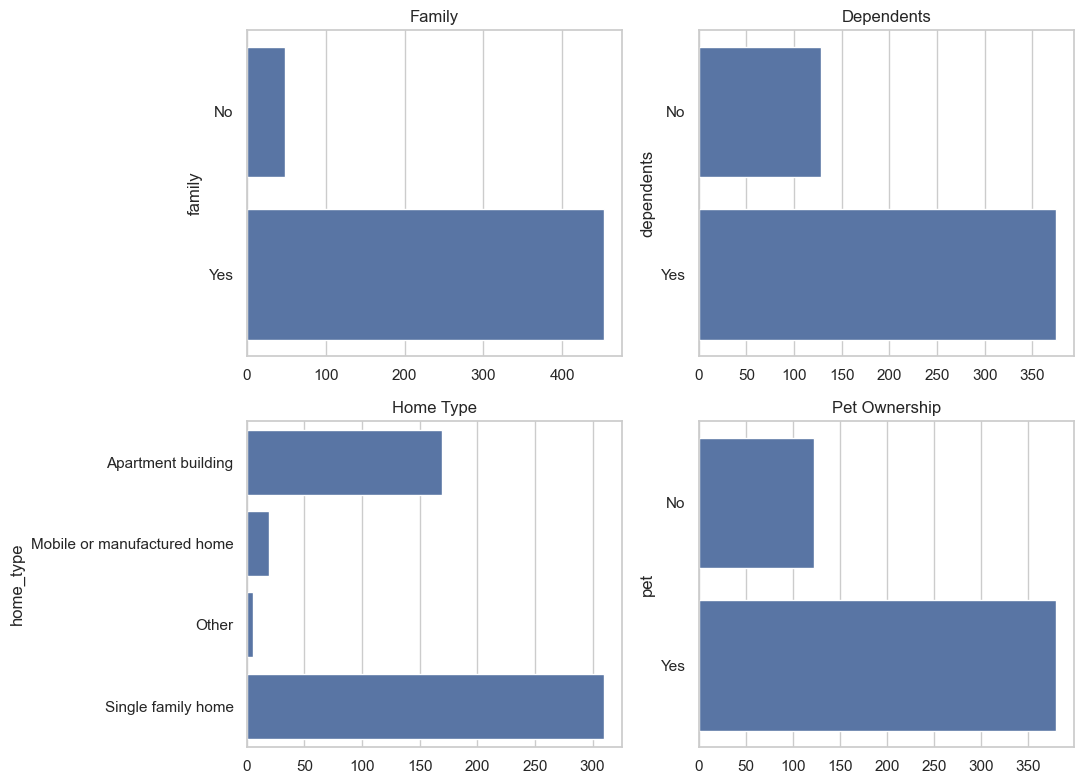

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

context_vars = ["family", "dependents", "home_type", "pet"]
titles = ["Family", "Dependents", "Home Type", "Pet Ownership"]

for ax, col, title in zip(axes, context_vars, titles):
    counts = (
        df[col]
        .astype("category")
        .value_counts()
    )
    sns.barplot(x=counts.values, y=counts.index, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


## 6. Experimental Condition and Selected Disaster

The dataset includes:
- `condition` (Standard vs AI-personalized)
- `alert_display` (e.g., layout or visualization style)
- `selected_disaster` (which scenario participants saw)

We can visualize:
- Participant counts per condition
- How conditions relate to selected disaster and alert display


### 6.1 Condition

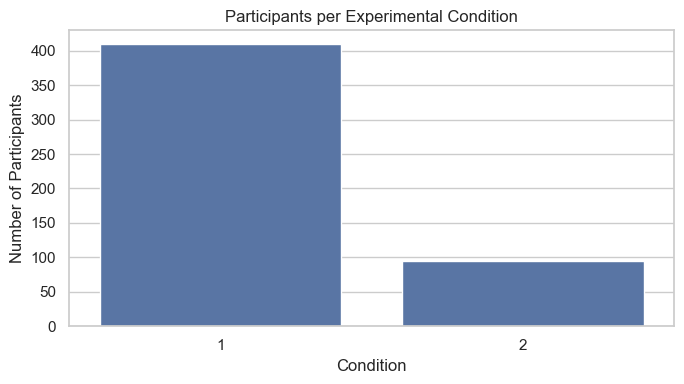

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))

cond_counts = (
    df["condition"]
    .fillna("Missing")
    .astype("category")
    .value_counts()
)

sns.barplot(x=cond_counts.index, y=cond_counts.values, ax=ax)
ax.set_xlabel("Condition")
ax.set_ylabel("Number of Participants")
ax.set_title("Participants per Experimental Condition")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


### 6.2 Selected Disaster

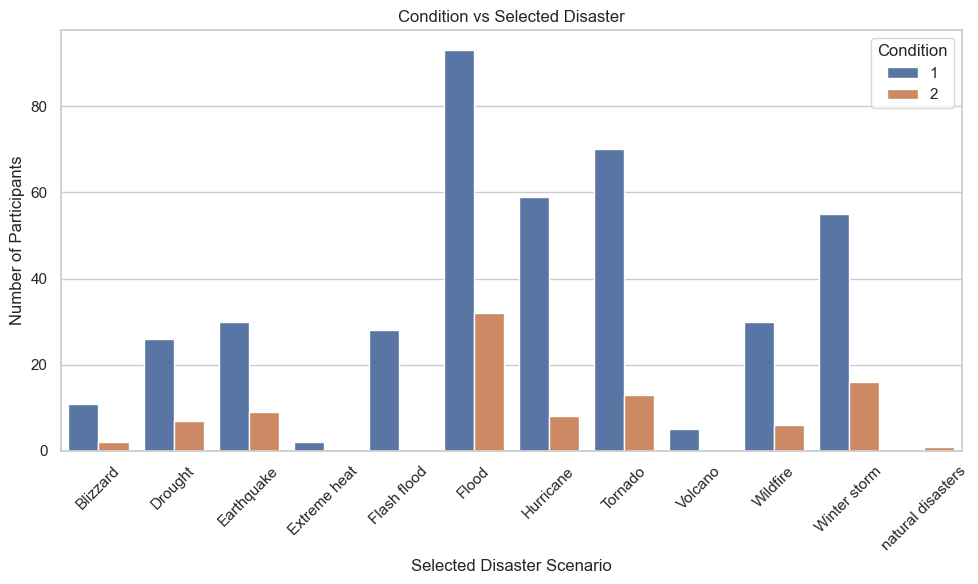

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
palette = {1: "#4C72B0", 2: "#DD8452"}

group_counts = (
    df.groupby(["condition", "selected_disaster"])
      .size()
      .reset_index(name="count")
)

sns.barplot(
    data=group_counts,
    x="selected_disaster",
    y="count",
    hue="condition",
    palette=palette,
    ax=ax
)
ax.set_xlabel("Selected Disaster Scenario")
ax.set_ylabel("Number of Participants")
ax.set_title("Condition vs Selected Disaster")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Condition")

plt.tight_layout()
plt.show()


## 7. Perception of Alerts: Likert-Scale Outcomes

The following columns capture participants' perceptions of the alert message:

- `clarity`
- `trust`
- `relevance`
- `influence`
- `confidence`
- `certainty`

We assume these are **Likert-type scales** (e.g., 1–5).


In [14]:
likert_cols = ["clarity", "trust", "relevance", "influence", "confidence", "certainty"]

df_likert = df[likert_cols]

df_likert.describe()


,clarity,trust,relevance,influence,confidence,certainty
count,503.000000,503.000000,503.000000,503.000000,503.000000,503.000000
mean,3.825050,3.962227,3.789264,3.757455,3.803181,3.673956
std,1.049193,0.986242,1.011549,1.031776,1.038612,1.099193
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
50%,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
75%,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


### 7.1 Distribution of Each Outcome

We create a **grid of histograms** for the Likert variables for condition 1 & 2.


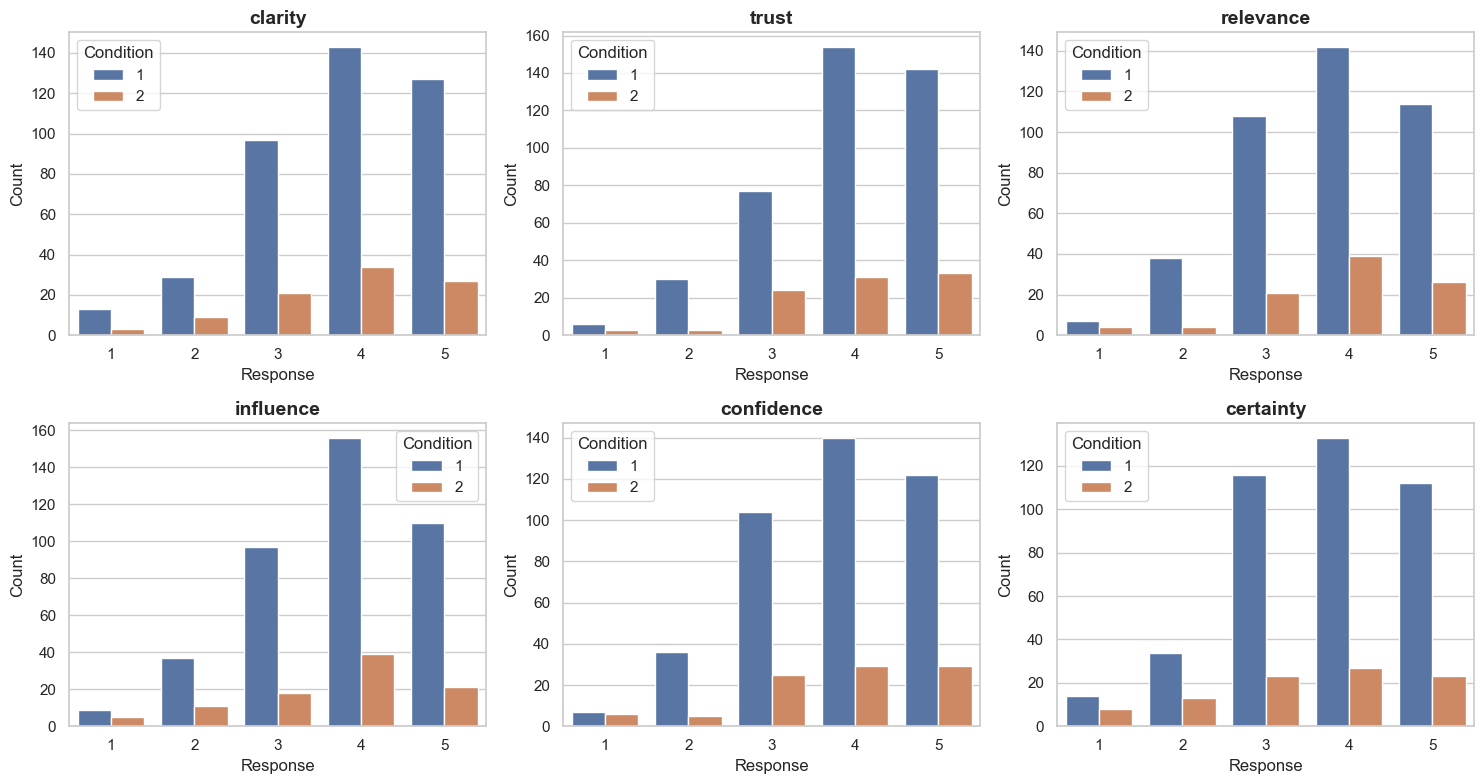

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


palette = {1: "#4C72B0", 2: "#DD8452"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, likert_cols):
    sns.countplot(
        data=df,
        x=col,
        hue="condition",
        palette=palette,
        ax=ax
    )
    
    ax.set_title(col, fontsize=14, fontweight="bold")
    ax.set_xlabel("Response")
    ax.set_ylabel("Count")
    ax.legend(title="Condition")

plt.tight_layout()
plt.show()

### 7.2 Mean Scores by Condition (Heatmap)

We compute the **mean** of each Likert outcome by experimental `Condition` and visualize it as a heatmap.


,clarity,trust,relevance,influence,confidence,certainty
condition,,,,,,
1,3.84,3.97,3.78,3.78,3.82,3.72
2,3.78,3.94,3.84,3.64,3.74,3.47


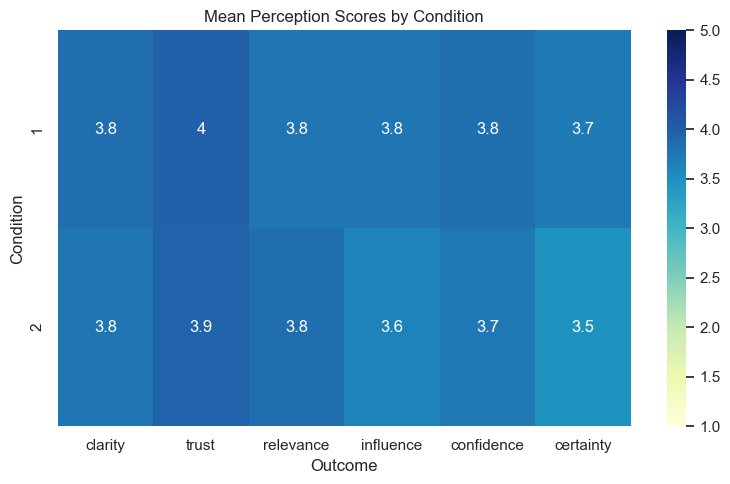

In [16]:
mean_by_condition = (
    df.groupby("condition")[likert_cols]
      .mean(numeric_only=True)
      .round(2)
)

display(mean_by_condition)

plt.figure(figsize=(8, 5))
sns.heatmap(mean_by_condition, annot=True, cmap="YlGnBu", vmin=1, vmax=5)
plt.title("Mean Perception Scores by Condition")
plt.xlabel("Outcome")
plt.ylabel("Condition")
plt.tight_layout()
plt.show()


### 7.3 Radar Plot of Perceptions by Condition

A **radar chart** provides a compact way to compare the overall profile of conditions across multiple outcomes.


In [17]:
mean_by_condition_reset = mean_by_condition.reset_index().rename(columns={"condition": "condition"})

fig = px.line_polar(
    mean_by_condition_reset.melt(id_vars="condition", value_vars=likert_cols,
                                 var_name="outcome", value_name="mean_score"),
    r="mean_score",
    theta="outcome",
    color="condition",
    line_close=True,
    range_r=[1, 5],
    title="Radar Plot of Perception Scores by Condition"
)
fig.show()


## 8 Correlations Among Perception Variables

We compute pairwise correlations among all Likert-scale variables to examine their relationships. 
Correlation matrices are generated for:

* All participants combined
* Participants from Condition 1 
* Participants from Condition 2


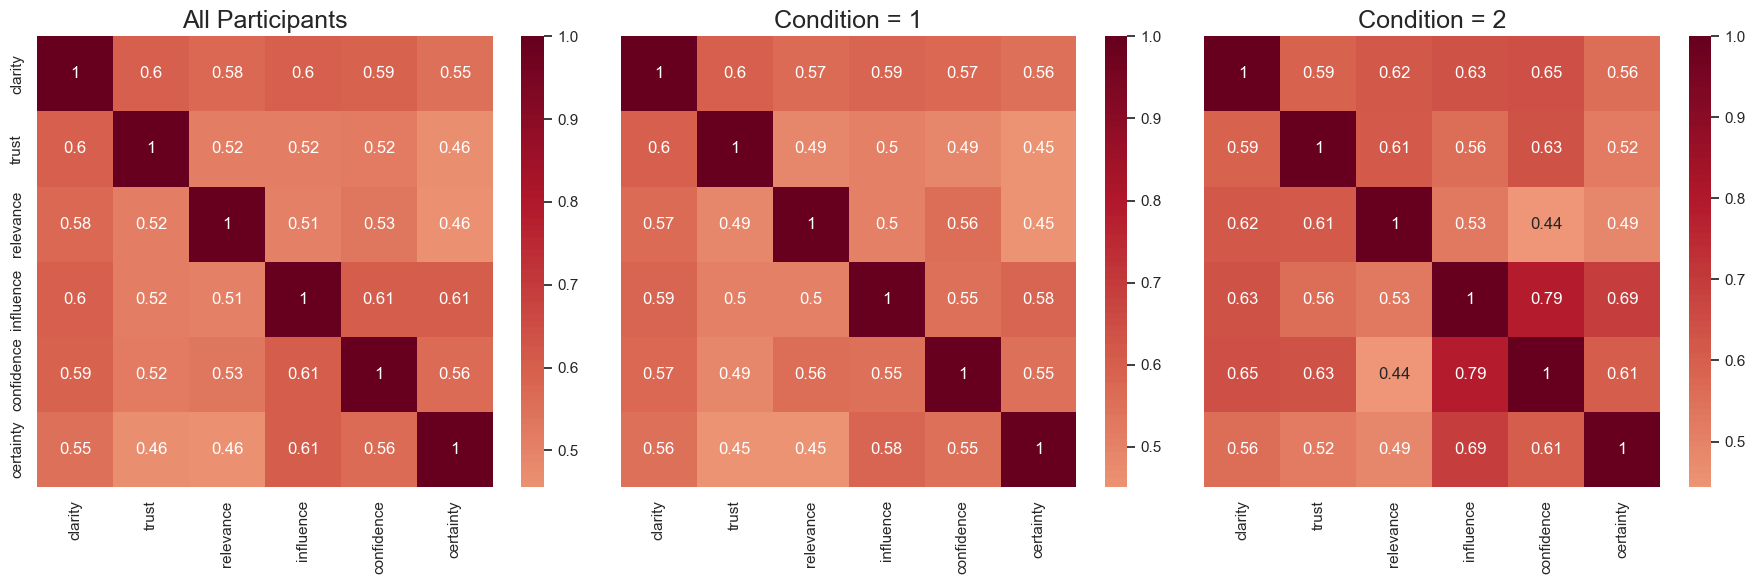

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Correlation for all participants
corr_all = df[likert_cols].corr(numeric_only=True)

# 2) Correlation for Condition = 1
corr_c0 = (
    df[df["condition"] == 1][likert_cols]
    .corr(numeric_only=True)
)

# 3) Correlation for Condition = 2
corr_c1 = (
    df[df["condition"] == 2][likert_cols]
    .corr(numeric_only=True)
)

# 4) Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

sns.heatmap(
    corr_all,
    annot=True,
    cmap="RdBu_r",
    center=0,
    ax=axes[0]
)
axes[0].set_title("All Participants", fontsize=18)

sns.heatmap(
    corr_c0,
    annot=True,
    cmap="RdBu_r",
    center=0,
    ax=axes[1]
)
axes[1].set_title("Condition = 1", fontsize=18)

sns.heatmap(
    corr_c1,
    annot=True,
    cmap="RdBu_r",
    center=0,
    ax=axes[2]
)
axes[2].set_title("Condition = 2", fontsize=18)

plt.tight_layout()
plt.show()